In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("C:/Users/Спасибо за покупку!/Documents/итоговый проект skillfactory/data_model_diplom.csv")


In [3]:
df.head()

,Rate,Drate,syn_flag_number,rst_flag_number,ack_flag_number,HTTP,HTTPS,DNS,SSH,TCP,...,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label,Attack
0,0.471037,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood,12
1,4.992473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood,23
2,31.735421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood,13
3,19365.300906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood,14
4,0.428021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood,20


In [4]:
#Проверяем целевую переменную
df["label"].value_counts()

label
DDoS-ICMP_Flood            180447
DDoS-UDP_Flood             136717
DDoS-TCP_Flood             113735
DDoS-PSHACK_Flood          103326
DDoS-SYN_Flood             102208
DDoS-RSTFINFlood           101819
DDoS-SynonymousIP_Flood     90480
DoS-UDP_Flood               83627
DoS-TCP_Flood               67697
DoS-SYN_Flood               51116
BenignTraffic               27709
Mirai-greeth_flood          24934
Mirai-udpplain              22536
Mirai-greip_flood           19279
DDoS-ICMP_Fragmentation     11402
MITM-ArpSpoofing             7840
DDoS-ACK_Fragmentation       7292
DDoS-UDP_Fragmentation       7224
DNS_Spoofing                 4570
Recon-HostDiscovery          3331
Recon-OSScan                 2433
Recon-PortScan               2082
DoS-HTTP_Flood               1805
VulnerabilityScan             913
DDoS-HTTP_Flood               709
DDoS-SlowLoris                622
DictionaryBruteForce          319
SqlInjection                  148
BrowserHijacking              134
CommandI

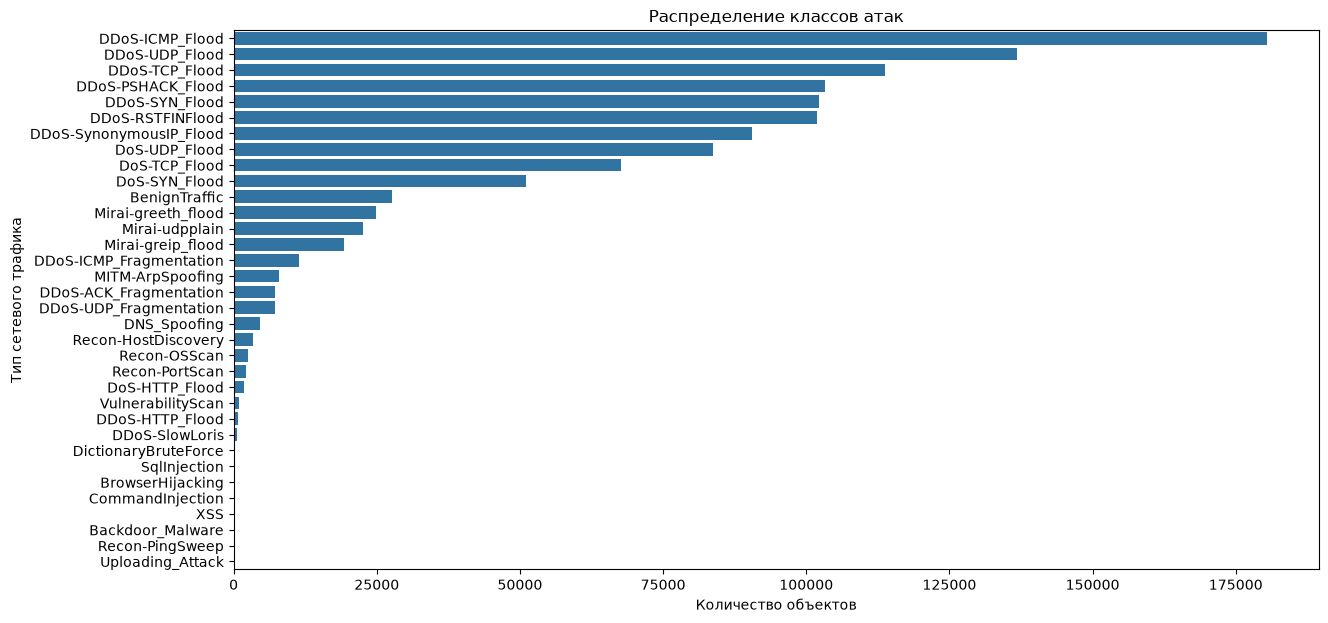

In [5]:
#Посмотрим на распредление типов атак
plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="label",
    order=df["label"].value_counts().index
)

plt.title("Распределение классов атак")
plt.xlabel("Количество объектов")
plt.ylabel("Тип сетевого трафика")

plt.show()

In [ ]:
## Подготовка целевой переменной

In [6]:
TARGET = "label"

In [7]:
X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]

In [8]:
X.shape
y.shape

(1176851,)

In [ ]:
## Кодирование классов атак

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [10]:
class_mapping = pd.DataFrame({
    "Encoded value": range(
        len(label_encoder.classes_)
    ),
    "Original label": label_encoder.classes_
})

class_mapping

,Encoded value,Original label
0,0,Backdoor_Malware
1,1,BenignTraffic
2,2,BrowserHijacking
3,3,CommandInjection
4,4,DDoS-ACK_Fragmentation
5,5,DDoS-HTTP_Flood
6,6,DDoS-ICMP_Flood
7,7,DDoS-ICMP_Fragmentation
8,8,DDoS-PSHACK_Flood
9,9,DDoS-RSTFINFlood


In [21]:
num_classes = len(
    label_encoder.classes_
)

print(
    "Количество классов:",
    num_classes
)

Количество классов: 34


In [ ]:
'''
Категориальная целевая переменная была преобразована в числовой формат с использованием LabelEncoder. 
При этом была сохранена таблица соответствия между числовыми кодами и исходными названиями атак.
Это позволяет использовать числовые классы во время обучения и восстанавливать понятное название атаки при последующей работе модели в API.
 '''

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [23]:
print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (941480, 30)
X_test: (235371, 30)
y_train: (941480,)
y_test: (235371,)


In [ ]:
'''
Датасет был разделён на обучающую и тестовую выборки в соотношении 80/20. Для сохранения пропорций классов атак использовался параметр stratify, 
что особенно важно для многоклассовой задачи с потенциально несбалансированным распределением сетевых атак.
'''

In [ ]:
## Нормализация признаков

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [15]:
baseline_features = [
    "Attack"
]

X_baseline = X[
    baseline_features
]

In [25]:
# Создаём baseline-датасет
X_baseline = X[
    baseline_features
]


# Делим данные на train и test
X_baseline_train, X_baseline_test, y_baseline_train, y_baseline_test = train_test_split(
    X_baseline,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# Нормализуем признаки
baseline_scaler = StandardScaler()

X_baseline_train_scaled = baseline_scaler.fit_transform(
    X_baseline_train
)

X_baseline_test_scaled = baseline_scaler.transform(
    X_baseline_test
)


# Создаём модель
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)


# Обучаем модель
baseline_model.fit(
    X_baseline_train_scaled,
    y_baseline_train
)


# Делаем предсказания
baseline_pred = baseline_model.predict(
    X_baseline_test_scaled
)


# Оцениваем результат
baseline_f1 = f1_score(
    y_baseline_test,
    baseline_pred,
    average="macro"
)


print(
    "Baseline Macro F1:",
    baseline_f1
)

Baseline Macro F1: 1.0


In [ ]:
'''
В качестве baseline была построена модель Logistic Regression, использующая ограниченный набор базовых сетевых характеристик. 
Полученное значение Macro F1 использовалось как отправная точка для оценки того,
насколько применение полного набора признаков и более сложных алгоритмов повышает качество классификации.
'''

In [26]:
print(
    classification_report(
        y_baseline_test,
        baseline_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                         precision    recall  f1-score   support

       Backdoor_Malware       1.00      1.00      1.00        18
          BenignTraffic       1.00      1.00      1.00      5542
       BrowserHijacking       1.00      1.00      1.00        27
       CommandInjection       1.00      1.00      1.00        24
 DDoS-ACK_Fragmentation       1.00      1.00      1.00      1458
        DDoS-HTTP_Flood       1.00      1.00      1.00       142
        DDoS-ICMP_Flood       1.00      1.00      1.00     36089
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      2280
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20665
       DDoS-RSTFINFlood       1.00      1.00      1.00     20364
         DDoS-SYN_Flood       1.00      1.00      1.00     20442
         DDoS-SlowLoris       1.00      1.00      1.00       124
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     18096
         DDoS-TCP_Flood       1.00      1.00      1.00     22747
         DDoS-UDP_Flood 

In [27]:
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
logreg_model.fit(
    X_train_scaled,
    y_train
)
logreg_pred = logreg_model.predict(
    X_test_scaled
)
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(
    X_train,
    y_train
)
rf_pred = rf_model.predict(
    X_test
)

c:\Users\Спасибо за покупку!\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
'''Logistic Regression использовалась в качестве интерпретируемой линейной модели. Она позволяет оценить, насколько классы сетевых атак разделимы с помощью линейных зависимостей.
 Полученные результаты использовались в качестве сравнения с нелинейными ансамблевыми алгоритмами.'''

In [ ]:
## XGBoost

In [17]:
xgb_model = XGBClassifier(
    objective="multi:softprob",

    num_class=num_classes,

    n_estimators=300,

    max_depth=8,

    learning_rate=0.1,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=-1
)
xgb_model.fit(
    X_train,
    y_train
)
xgb_pred = xgb_model.predict(
    X_test
)

In [ ]:
'''XGBoost использовался как градиентный ансамблевый алгоритм, способный моделировать сложные нелинейные зависимости. 
В рамках проекта оценивалось, насколько последовательное исправление ошибок предыдущих деревьев позволяет повысить качество обнаружения отдельных типов сетевых атак.'''

In [ ]:
## LightGBM

In [18]:
lgbm_model = LGBMClassifier(
    objective="multiclass",

    num_class=num_classes,

    n_estimators=300,

    learning_rate=0.1,

    num_leaves=64,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1,

    verbosity=-1
)
lgbm_model.fit(
    X_train,
    y_train
)
lgbm_pred = lgbm_model.predict(
    X_test
)

In [ ]:
'''LightGBM был выбран в качестве дополнительной градиентной модели для сравнения с XGBoost.
 Особый интерес представляло сравнение качества моделей на большом объёме сетевых данных и оценка способности алгоритма распознавать редкие классы атак.'''

In [19]:
## Функция оценки моделей
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision Macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Recall Macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "F1 Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [28]:
results = []
results.append(
    evaluate_model(
        "Baseline",
        y_baseline_test,
        baseline_pred
    )
)
results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logreg_pred
    )
)
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)
results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)
results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_pred
    )
)
results_df = pd.DataFrame(
    results
)
results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
)
results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0,Baseline,1.000000,1.000000,1.000000,1.000000,1.000000
4,LightGBM,0.999979,0.999980,0.999824,0.999902,0.999979
3,XGBoost,0.999983,0.999304,0.999358,0.999324,0.999983
2,Random Forest,0.998840,0.984513,0.956087,0.967833,0.998838
1,Logistic Regression,0.992153,0.810059,0.935774,0.845722,0.992676


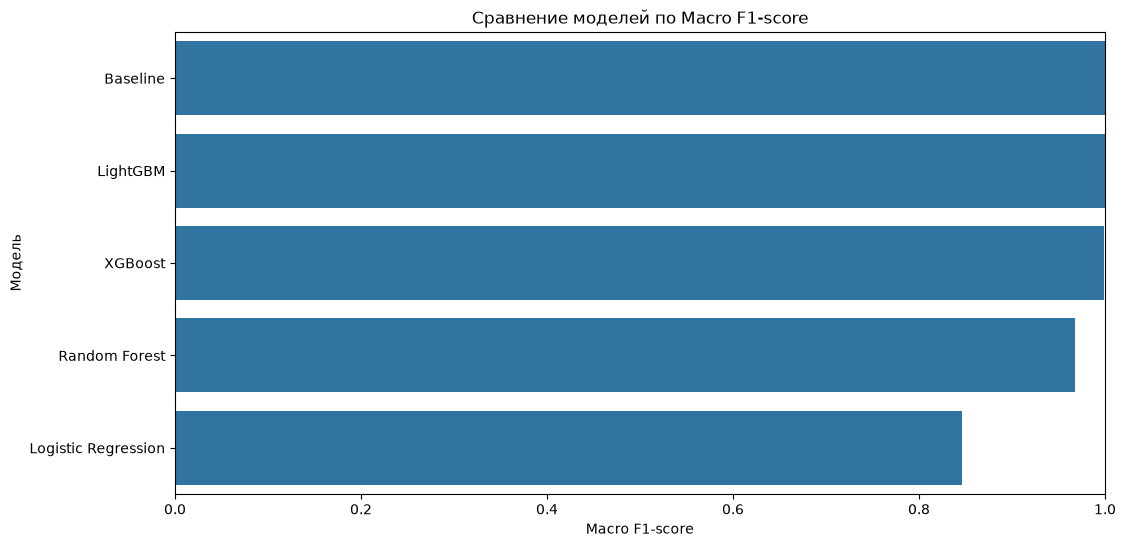

In [29]:
## Сравнение моделей

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="F1 Macro",
    y="Model"
)

plt.title(
    "Сравнение моделей по Macro F1-score"
)

plt.xlabel(
    "Macro F1-score"
)

plt.ylabel(
    "Модель"
)

plt.xlim(0, 1)

plt.show()

In [ ]:
'''Для сравнения моделей основным критерием был выбран Macro F1-score. Это позволяет одинаково учитывать качество классификации как часто встречающихся, так и редких типов сетевых атак. 
Accuracy использовалась как дополнительная метрика, поскольку при дисбалансе классов она может давать слишком оптимистичную оценку качества.'''

In [ ]:
## Выбор лучшей модели

In [30]:
best_model_name = results_df.iloc[0]["Model"]

print(
    "Лучшая модель:",
    best_model_name
)

trained_models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

full_models_results = results_df[
    results_df["Model"] != "Baseline"
]

best_model_name = full_models_results.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Финальная модель:",
    best_model_name
)

Лучшая модель: Baseline
Финальная модель: LightGBM


In [31]:
#Отчет по лучшей модели
best_pred = best_model.predict(
    X_test
)
print(
    classification_report(
        y_test,
        best_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                         precision    recall  f1-score   support

       Backdoor_Malware       1.00      1.00      1.00        18
          BenignTraffic       1.00      1.00      1.00      5542
       BrowserHijacking       1.00      1.00      1.00        27
       CommandInjection       1.00      1.00      1.00        24
 DDoS-ACK_Fragmentation       1.00      1.00      1.00      1458
        DDoS-HTTP_Flood       1.00      1.00      1.00       142
        DDoS-ICMP_Flood       1.00      1.00      1.00     36089
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      2280
      DDoS-PSHACK_Flood       1.00      1.00      1.00     20665
       DDoS-RSTFINFlood       1.00      1.00      1.00     20364
         DDoS-SYN_Flood       1.00      1.00      1.00     20442
         DDoS-SlowLoris       1.00      1.00      1.00       124
DDoS-SynonymousIP_Flood       1.00      1.00      1.00     18096
         DDoS-TCP_Flood       1.00      1.00      1.00     22747
         DDoS-UDP_Flood 

In [ ]:
'''Наилучший результат показала модель LightGBM с Macro F1-score = X.XX. Это свидетельствует о том, что градиентный бустинг лучше остальных рассмотренных алгоритмов справляется с классификацией типов сетевого трафика в данном наборе данных.

Но обязательно нужно посмотреть качество по каждому классу.

Например:

DDoS-UDP_Flood       F1 = 0.99
Recon-PortScan       F1 = 0.82
Mirai-greeth_flood   F1 = 0.61

Тогда нельзя писать:

модель идеально обнаруживает атаки.

Правильнее:

модель демонстрирует высокое среднее качество, однако для отдельных редких классов качество ниже, что требует дополнительного анализа дисбаланса данных и оптимизации классификации редких атак.
'''

In [32]:
#Сохранение модели
models_dir = Path(
    "../models"
)

models_dir.mkdir(
    exist_ok=True
)
joblib.dump(
    best_model,
    models_dir / "best_model.pkl"
)
joblib.dump(
    scaler,
    models_dir / "scaler.pkl"
)
joblib.dump(
    label_encoder,
    models_dir / "label_encoder.pkl"
)
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    models_dir / "feature_names.pkl"
)
results_df.to_csv(
    models_dir / "model_results.csv",
    index=False
)

In [ ]:
'''Для дальнейшего использования модели были сериализованы не только параметры классификатора, но и все необходимые компоненты pipeline: масштабатор, кодировщик целевой переменной и список признаков. 
Это обеспечивает воспроизводимость обработки данных при интеграции модели в API.'''

In [ ]:
'''
В рамках проекта была разработана система многоклассовой классификации сетевого трафика на основе датасета CICIoT2023. 
В качестве целевой переменной использовался исходный признак label, содержащий информацию о конкретном типе сетевой активности или атаки.
Были реализованы и сравнены модели Logistic Regression, Random Forest, XGBoost и LightGBM. 
Для оценки качества использовались Accuracy, Precision, Recall, Macro F1 и Weighted F1. 
Основной метрикой был выбран Macro F1-score, поскольку он позволяет одинаково учитывать качество классификации различных классов, 
включая редкие типы атак.
На основании результатов сравнения была выбрана модель с наилучшим значением Macro F1. 
Дополнительно был проведён анализ ошибок классификации с использованием Classification Report и Confusion Matrix. 
Для интерпретации решений модели использовался SHAP, позволивший определить влияние сетевых характеристик на предсказания.
Финальная модель и необходимые компоненты предварительной обработки были сериализованы в формате .pkl. 
На следующем этапе модель была интегрирована в FastAPI-сервис, 
который принимает параметры сетевого трафика и возвращает предполагаемый тип активности и вероятность предсказания.
В результате был создан прототип ML-based Network Intrusion Detection Service, который может использоваться как дополнительный аналитический компонент SOC для автоматической классификации сетевого трафика и поддержки специалистов по информационной безопасности.
'''

In [ ]:
'''Для повышения прозрачности работы модели был проведён анализ решений с использованием метода SHAP. 
Это позволило определить вклад отдельных сетевых характеристик в итоговое предсказание модели.
Глобальный анализ SHAP позволил выявить признаки, оказывающие наибольшее влияние на классификацию сетевого трафика. 
Локальный анализ отдельных объектов позволил определить причины отнесения конкретного сетевого потока к определённому типу атаки.
Такой подход особенно важен для SOC, поскольку позволяет специалисту не только получить автоматическое уведомление об атаке,
 но и понять, какие характеристики сетевого трафика повлияли на решение модели. 
 Это повышает доверие к ML-системе и облегчает процесс проверки срабатываний аналитиком.'''